Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°6**
##**Tema**: Aplicaciones de AG - Tachos

* Mamani, Pablo Ariel
* Monteros, Maria Milagros
* Rocha, Felipe

## Ejercicio 1
Se tiene el siguiente modelo simplificado del funcionamiento de un sector de una fábrica de azúcar: Se tienen **N** tachos de cocimiento, cada uno de los cuales consume vapor de una determinada manera a lo largo del tiempo. El consumo total de vapor puede calcularse como la suma del consumo de vapor individual de cada tacho. El tiempo entre que empieza a consumir el primer tacho hasta que deja de consumir el último tacho es **tMAX** (llamado tiempo total del ciclo o *timespan*). Durante este tiempo, el consumo de vapor varía en el tiempo, consumiendo mayor energía mientras mayor sea esta variación. Este problema consiste en reducir la energía que se consume por la variación de vapor a lo largo del ciclo de cocimiento de la azúcar. A continuación se brindan detalles del modelado del problema:


Un tacho de cocimiento consume vapor durante un lapso de tiempo. El proceso arranca en el tiempo t0, y finaliza en t1 = t0+1 donde ya se consumió todo el vapor del tacho. Es decir, el proceso dura *una unidad de tiempo*. Este comportamiento se puede modelar como una parábola con las ramas hacia abajo, donde alcanza su máximo en t = 1, y está definida en el intervalo  t0 ≤ t ≤ t0+1, siendo nulo fuera de dicho intervalo. Es decir:

  * VaporTacho_i(t) = **0**, *si 0 ≤ t ≤ t0*
  * VaporTacho_i(t) = **1 - (2 * t0 - 2t + 1)^2**, *si t0 ≤ t ≤ t0+1*
  * VaporTacho_i(t) = **0**, *si t1 ≤ t ≤ tMAX*








Consumo de vapor para un tacho, tomando como ejemplo t0 = 1.000000


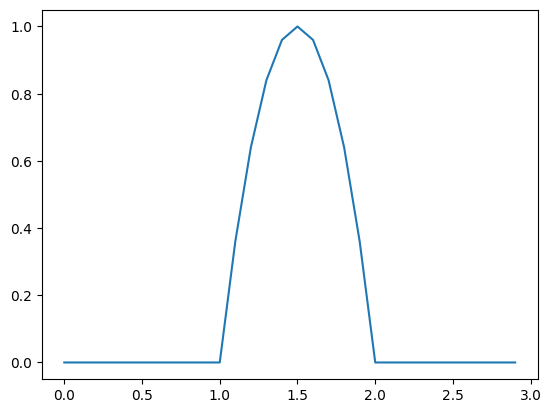

In [21]:
def VaporTacho_i(t, t0):
  return 1 - (2*t0-2*t + 1)**2 if t > t0 and t < t0+1 else 0

import matplotlib.pyplot as plt
t0 = 1
intervalo = [x/10 for x in range(30)]
vt = [VaporTacho_i(t,t0) for t in intervalo]
plt.figure()
plt.plot(intervalo, vt);
print('Consumo de vapor para un tacho, tomando como ejemplo t0 = %f'%t0)

Ahora suponga que la fábrica cuenta con una cantidad de tachos de cocimiento **N** que puede variar entre 5 y 20. Los tachos arrancan de manera
independiente entre ellos, y el vapor total puede ser calculado en cada instante de tiempo sumando el vapor producido por cada tacho. Es decir:

* VaporTotal(t) = SUM_i { VaporTacho_i(t) }

Consumo de vapor total con dos tachos, tomando como ejemplo t0 = 0.800000 y t0=1.100000


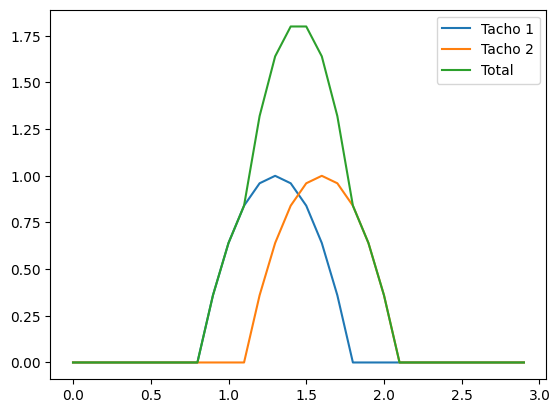

In [22]:
def VaporTotal(t_inicios, intervalo):
  return [sum([VaporTacho_i(t,t0) for t0 in t_inicios]) for t in intervalo]

t0_1 = 0.8
t0_2 = 1.1
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
vtotal = VaporTotal([t0_1, t0_2], intervalo)
plt.plot(intervalo, vtotal, label='Total');
plt.legend()
print('Consumo de vapor total con dos tachos, tomando como ejemplo t0 = %f y t0=%f'%(t0_1,t0_2))

El objetivo del problema es diseñar un Algoritmo Genético que organice el cronograma de arranques (*Schedule*) de los tachos, de manera que:
* Todos los tachos deben completar su ciclo.
* Se estabilizce el consumo de vapor total (que no existan grandes variaciones de vapor durante todo el proceso). Es decir, se prefieren soluciones que produzcan un consumo de vapor "*constante*".
* Se prefieren soluciones que brinden un tiempo total de funcionamiento menor.
* Se debe evitar la convergencia hacia las soluciones triviales e incorrectas:
* El algoritmo debe ser general, funcionando para diferente cantidad de tachos **N**.
  * Donde el tiempo total es mínimo debido a que todos los tachos arrancan juntos.
  * Los tachos arrancan uno despues de otro (no se superponen).



Soluciones triviales a evitar:


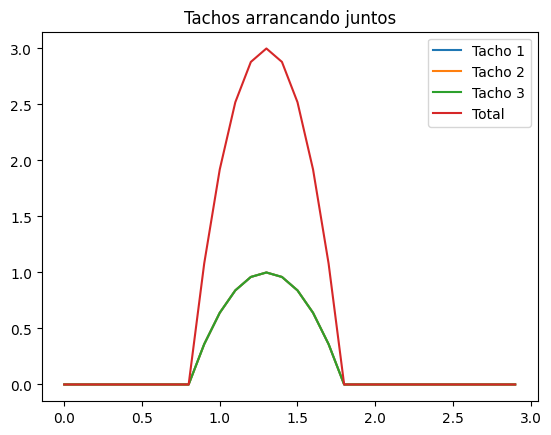

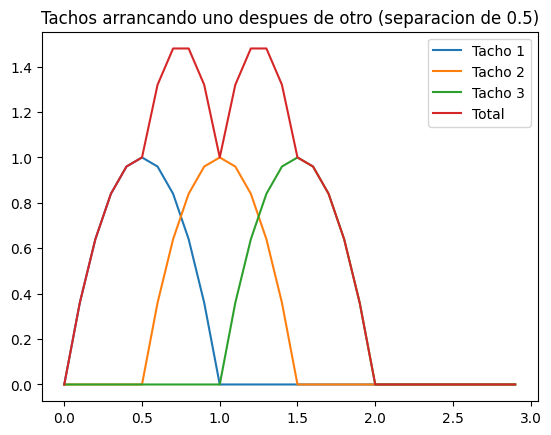

In [23]:
t0_1 = 0.8
t0_2 = 0.8
t0_3 = 0.8
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
plt.plot(intervalo, vt3, label='Tacho 3');
plt.plot(intervalo, vtotal, label='Total');
plt.legend()
plt.title('Tachos arrancando juntos')

t0_1 = 0
t0_2 = t0_1 + 0.5 # Separado por 0.5 unidades
t0_3 = t0_2 + 0.5 # Separado por 0.5 unidades
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.figure()
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
plt.plot(intervalo, vt3, label='Tacho 3');
plt.plot(intervalo, vtotal, label='Total');
plt.legend()
plt.title('Tachos arrancando uno despues de otro (separacion de 0.5)')
print("Soluciones triviales a evitar:")


Se pide:
1. Determinar una codificación adecuada (forma de representar las soluciones  para el problema).
2. Definir las restricciones para los valores en la solución (determinar la matriz de *Bounds*).
3. En base a la codificación elegida, definir una función *Fitness* que permita encontrar buenas soluciones en base a los objetivos del problema.
4. Determinar una arquitectura de algoritmos genéticos adecuada para resolver el problema:
  * Definir que tipo de algoritmo genético utilizar.
  * Elegir los operadores genéticos a utilizar.
5. Ajustar los parámetros adecuadamentes usando los criterios utilizados en los prácticos anteriores. La cantidad de generaciones y tamaño de la población pueden variar al tomar diferentes cantidad de tachos presentes.

La función fitness, entonces, deberá tener en cuenta las variaciones de vapor total en el tiempo, y el tiempo total del ciclo.

In [ ]:
import random, math

def geneticoSimple(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
                   cant_cruzados, cant_mutados, cant_elite, param_sel, f, callback=None,\
                    max_iter_sin_mejora=None):

    sol = []
    solF = None
    cant_soluc = len(Pop)
    Fit = [None] * cant_soluc
    traceBest = []
    traceAvg = []
    bestSols = []
    mejor_fitness = None
    iter_sin_mejora = 0

    if cant_soluc < 2:
        print("La poblacion debe tener al menos 2 individuos")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    cant_variables = len(Pop[0])
    if len(Bounds) != cant_variables or len(Bounds[0]) != 2:
        print("El tamaño de la matriz no es el correcto")
        return sol, solF, Pop, Fit,  traceBest, traceAvg, bestSols
    if len(Enteras) != cant_variables:
        print(Enteras, cant_variables)
        print("El tamaño del vector no es el correcto")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_cruzados > cant_soluc:
        print("La cantidad de cruzados debe ser menor que el tamaño de la poblacion")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_mutados > cant_soluc:
        print("La cantidad de mutados debe ser menor que el tamaño de la poblacion")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_elite > cant_soluc:
        print("La cantidad de elite debe ser menor que el tamaño de la poblacion")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    cb_param = None
    p = [i for i in range(cant_soluc)]

    for k in range(cant_soluc):
      Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
      Fit[k] = f(Pop[k])
    if callback != None:
        cb_param = callback(Pop, Fit, Bounds, 0, cant_generac, cb_param)

    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    mejor_fitness = Fit[p_orden[0]]

    for gen in range(cant_generac):

        Elite = [[xi for xi in Pop[p_orden[k]]] for k in range(cant_elite)]
        Elite_Fit = [Fit[p_orden[k]] for k in range(cant_elite)]
        p_sel = sel(Fit, cant_soluc, param_sel)
        random.shuffle(p)
        Pop = [Pop[p_sel[k]] for k in p]
        Fit = [Fit[p_sel[k]] for k in p]
        random.shuffle(p)
        xover_list = xover if isinstance(xover, list) else [xover]

        for k in range(0, cant_cruzados-1, 2):
            xover_op = random.choice(xover_list)
            c1, c2 = xover_op(Pop[p[k]], Pop[p[k+1]])
            Pop[p[k]] = [xi for xi in c1]
            Pop[p[k+1]] = [xi for xi in c2]
            Fit[p[k]] = None
            Fit[p[k+1]] = None

        random.shuffle(p)
        mut_list = mut if isinstance(mut, list) else [mut]
        for k in range(cant_mutados):
          mut_op = random.choice(mut_list)
          C = mut_op(Pop[p[k]], Bounds)
          Pop[p[k]] = [xi for xi in C]
          Fit[p[k]] = None

        random.shuffle(p)
        for k in range(cant_elite):
          Pop[p[k]] = Elite[k]
          Fit[p[k]] = Elite_Fit[k]

        random.shuffle(p)
        for k in range(cant_soluc):
          if Fit[k] == None:
            Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
            Fit[k] = f(Pop[k])


        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)

        fitness_actual = Fit[p_orden[0]]

        if fitness_actual > mejor_fitness :
            mejor_fitness = fitness_actual
            iter_sin_mejora = 0
        else:
            iter_sin_mejora += 1


        traceBest.append(Fit[p_orden[0]])
        traceAvg.append(sum(Fit) / len(Fit))
        bestSols.append([xi for xi in Pop[p_orden[0]]])

        if callback != None:
            cb_param = callback(Pop, Fit, Bounds, gen, cant_generac, cb_param)

        if max_iter_sin_mejora is not None and iter_sin_mejora >= max_iter_sin_mejora:
            print(f"Terminación anticipada: {iter_sin_mejora} iteraciones sin mejora (Generación {gen+1})")
            break

    solF = Fit[p_orden[0]]
    sol = Pop[p_orden[0]]

    return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from time import sleep

def graficarEvolucionFitness(best, mean):
  fig = plt.figure()
  ax = plt.axes()
  x = range(len(best))
  plt.plot(x, best, label='Mejor')
  plt.plot(x, mean, label='Promedio')
  plt.title('Valores de Evaluación')
  plt.xlabel('Iteracion')
  plt.ylabel('Fitness')
  plt.grid()
  plt.legend()




In [ ]:
import random
def sel_ruleta(F, cant_selectos, eps):
    min_fitness = min(F)
    ajustado = [f - min_fitness + eps for f in F]
    suma_fitness = sum(ajustado)
    probabilidades = [f / suma_fitness for f in ajustado]
    ruleta = []
    acumulado = 0
    
    for p in probabilidades:
        acumulado += p
        ruleta.append(acumulado)

    S = []
    for _ in range(cant_selectos):
        r = random.random()
        for i, valor_ruleta in enumerate(ruleta):
            if r <= valor_ruleta:
                S.append(i)
                break
    return S

def sel_sus(F, cant_selectos, eps):
    peor = min(F) 
    F = [(i-peor+eps) for i in F] 
    pesoTotal = sum(F)
    prob = [(i/pesoTotal) for i in F] 
    ruleta = []
    acumulada = 0
    for i in prob:
      acumulada = acumulada + i
      ruleta.append(acumulada)
    p = random.uniform(0, 1/cant_selectos)
    puntosParaEleccion = [(p + i/cant_selectos) for i in range(cant_selectos)]
    S = []
    for i in puntosParaEleccion:
      for j in range(len(ruleta)):
        if i <= ruleta[j]:
          S.append(j)
          break
    return S

def mut_step(P, Bounds):
    C = P.copy()
    cut = random.randint(0,len(P)-1)
    if random.randint(0,1) == 0:
        C[cut] = random.random() * (Bounds[cut][1] - P[cut]) + P[cut]
    else:
        C[cut] = random.random() * (P[cut] - Bounds[cut][0]) + P[cut]

    return C
def mut_boundary(P, Bounds):
    C = P.copy()
    cut = random.randint(0,len(P)-1)
    C[cut] = Bounds[cut][random.randint(0,1)]
    return C

def mut_swap(p, Bounds, n=1):
    m = p.copy()
    r = list(range(len(m)-1))
    random.shuffle(r)
    o = r[:n]
    d = r[n:2*n]

    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_adjoin_swap(p, n=1):
    m = p.copy()
    r = list(range(len(m)-1)) 
    random.shuffle(r)
    o = r[:n]
    d = [(x + 1) for x in o]  
   
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_inversion(p):
    m = p.copy()
    r = list(range(len(m)))
    random.shuffle(r)
    o = [x for x in range(min(r[:2]), max(r[:2]))]
    
    for i in range(len(o)):
        m[o[i]] = p[o[-i-1]]
    return m


def xov_arith(P1, P2, explore=0):
    a = random.random() * (1 + explore)
    C1 = [P1[i] * a + P2[i] * (1-a) for i in range(len(P1))]
    C2 = [P1[i] * (1-a) + P2[i] * a for i in range(len(P1))]
    return C1, C2

def xov_uniform(P1, P2):
    mascara = [random.randint(0,1) for i in range(len(P1))]
    C1 = [P1[i] if a == 0 else P2[i] for i, a in enumerate(mascara)]
    C2 = [P2[i] if a == 0 else P1[i] for i, a in enumerate(mascara)]
    return C1, C2


def xov_cube(P1, P2):
    C1 = []
    C2 = []
    for i in range(len(P1)):
        lo = min(P1[i], P2[i])
        hi = max(P1[i], P2[i])
        C1.append(random.uniform(lo, hi))
        C2.append(random.uniform(lo, hi))
    return C1, C2


def initPop(cant_individuos, bounds):
  pop = [[random.uniform(b[0], b[1]) for b in bounds] for i in range(cant_individuos)]
  return pop

In [ ]:
import statistics

def penalizacion(sol, K=10):
    n= len(sol)
    sep_min= (3*n)/80
    sol_ordenado = sorted(sol)
    P = 0
    for i in range(len(sol_ordenado) - 1):
        dist = sol_ordenado[i+1] - sol_ordenado[i]
        if dist < sep_min:
           P += K *  (sep_min - dist)**3
    return P


def varianza(VaporTotal):
  var = statistics.variance(VaporTotal)
  return var

def tiempo_ciclo(solucion):
  tiempo = max(solucion)  - min(solucion)
  return tiempo

def fitnessTachos(x_vars):
  t_min =0
  t_max=10
  intervalo = np.linspace(t_min+0.5, t_max-0.5, 300)
  objetivo_1 = varianza(VaporTotal(x_vars, intervalo)) 
  objetivo_2 =  tiempo_ciclo(x_vars) 
  pen = penalizacion(x_vars)
  alpha = 0.25
  return -(1 - alpha)*objetivo_1 - (alpha*objetivo_2) - pen


Terminación anticipada: 50 iteraciones sin mejora (Generación 377)
Mejor solución: [6.565549140810759, 4.722247277769338, 6.23138208699077, 5.4647122868650975, 5.832686424414668, 3.9564359234331574, 4.327875573761096, 5.08688083351286, 3.2228538973234855, 3.563865457514712] (Fitness: -1.3606149014497404)
Tiempo ciclo: 3.342695243487274


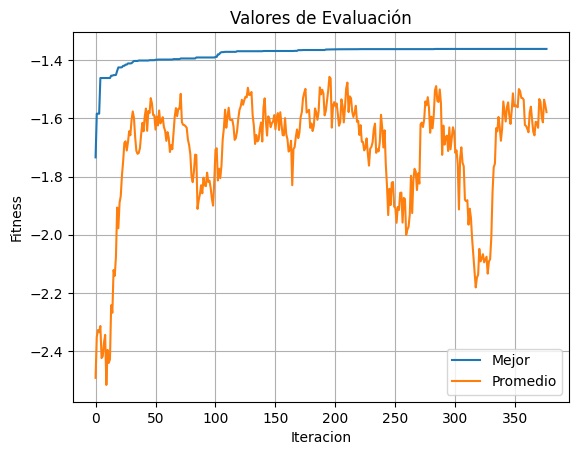

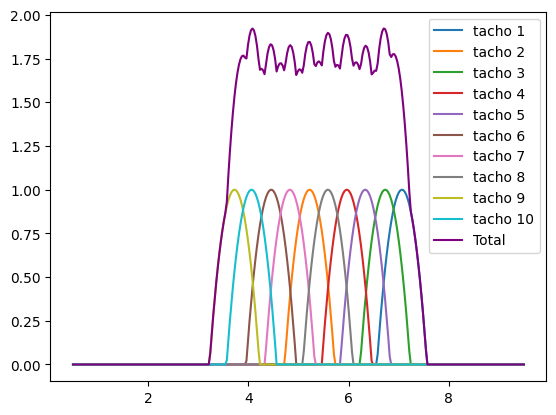

In [27]:
n = 10
t_min=0
t_max=10
intervalo = np.linspace(t_min+0.5, t_max-0.5, 300)
Bounds = [[0, n-1]]*n
Enteras = [False]*n
f = fitnessTachos
cant_individuos = 50
cant_generac = 1000
cant_elite = 1
sel = sel_sus
eps = 0.1
xover = [xov_cube, xov_arith]
cant_cruzados = round(0.6 * cant_individuos)
mut = [mut_step, mut_boundary, mut_swap]
cant_mutados = round(0.1* cant_individuos)

max_iter_sin_mejora = 50

Pop = initPop(cant_individuos, Bounds)
sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
     geneticoSimple(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
         cant_cruzados, cant_mutados, cant_elite, eps, f, None, max_iter_sin_mejora)

print("Mejor solución: {0} (Fitness: {1})".format(sol, solF))
print("Tiempo ciclo: {0}".format(tiempo_ciclo(sol)))

graficarEvolucionFitness(traceBest, traceAvg)
vtotal = VaporTotal(sol, intervalo)
plt.figure()
for i in range(len(sol)):
  trazo = [VaporTacho_i(t, sol[i]) for t in intervalo]
  plt.plot(intervalo, trazo, label="tacho {0}".format(i+1))
plt.plot(intervalo, vtotal, label='Total', color="purple")
plt.legend()


# Conclusiones

A partir de las parabolas graficadas que reflejan el consumo de vapor y de la función fitness que combina estabilidad, tiempo total del ciclo y penalizaciones por arranquesdemasiado cercanos, el algormitmo diseñado logró generar cronogramas mucho más equilibrados que los esquemas triviales planteados al principio.

Las gráficas que logramos, muestran que los arranques se distribuyen de forma ordenada, con ciertas superposiciones que reducen las variaciones abruptas del consumo total de vapor.

Usamos operadores variados de cruzamiento y mutación, lo que nos permitió mantener diversidad en población y evitar soluciones pobres o trivialmente repetidas.